# Real-Time DDoS Attack Detection Using Graph Neural Networks
## CICDDoS2019 Dataset — Final Year Project

**Stack:** PyTorch · PyTorch Geometric · NetworkX · Scikit-learn · XGBoost

This notebook implements a production-grade pipeline: preprocessing → graph construction → GCN/GAT + baselines → evaluation → deployment artifacts.

> LAN simulation is **not** included. Only **CICDDoS2019**.

## 1. Problem Definition

**Goal:** Detect DDoS attacks from network flow records in near real time.

**Graph formulation:** Each IP is a **node**; each flow is a directed **edge** (source → destination). Node features aggregate flow statistics; labels indicate malicious involvement.

| DSA Concept | Usage |
|-------------|--------|
| Graph | IP-flow communication topology |
| Hash map | O(1) IP → node index |
| Arrays | Features, labels, masks |
| Matrices | Feature matrix **X**, sparse adjacency |
| BFS / DFS | Subgraph viz & attack-region traversal |
| Adjacency | PyG `edge_index` (COO sparse format) |
| Priority (concept) | GAT attention ranks neighbors |

## 2. Environment Setup

In [1]:
import logging
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ddos_gnn.config import ARTIFACTS_DIR, DATA_PATH, DEVICE, FIGURES_DIR, MAX_FLOWS, MODELS_DIR, RANDOM_SEED
from ddos_gnn.inference import ensure_artifact_dirs

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("ddos_gnn_notebook")

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
ensure_artifact_dirs(ARTIFACTS_DIR, MODELS_DIR, FIGURES_DIR)
logger.info("Device: %s | MAX_FLOWS=%s", DEVICE, MAX_FLOWS)
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

15:32:44 | INFO | Artifact dir ready: C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\artifacts


15:32:44 | INFO | Artifact dir ready: C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\artifacts\models


15:32:44 | INFO | Artifact dir ready: C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\artifacts\figures


15:32:44 | INFO | Device: cpu | MAX_FLOWS=80000


PyTorch 2.8.0+cpu | Device: cpu


## 3. Dataset Loading

In [2]:
from ddos_gnn.data_loader import load_cic_ddos

df_raw = load_cic_ddos(DATA_PATH)
logger.info("Loaded: %s", df_raw.shape)
df_raw.head(3)

15:32:46 | INFO | Loading dataset from C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\CICDDoS.csv


15:32:51 | INFO | Loaded shape=(225745, 85)


15:32:51 | INFO | Loaded: (225745, 85)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 4. Exploratory Data Analysis (EDA)

In [3]:
from ddos_gnn.visualization import plot_correlation_heatmap, plot_label_distribution

fig_dist = plot_label_distribution(df_raw, "Label", FIGURES_DIR / "label_distribution.html")
fig_dist.show()
display(df_raw.describe().T.head(12))
df_raw["Label"].value_counts()

,count,mean,std,min,25%,50%,75%,max
Source Port,225745.0,3.825757e+04,2.305730e+04,0.0,18990.0,4.979900e+04,5.829600e+04,6.553400e+04
Destination Port,225745.0,8.879619e+03,1.975465e+04,0.0,80.0,8.000000e+01,8.000000e+01,6.553200e+04
Protocol,225745.0,7.600288e+00,3.881586e+00,0.0,6.0,6.000000e+00,6.000000e+00,1.700000e+01
Flow Duration,225745.0,1.624165e+07,3.152437e+07,-1.0,71180.0,1.452333e+06,8.805237e+06,1.199999e+08
Total Fwd Packets,225745.0,4.874916e+00,1.542287e+01,1.0,2.0,3.000000e+00,5.000000e+00,1.932000e+03
Total Backward Packets,225745.0,4.572775e+00,2.175536e+01,0.0,1.0,4.000000e+00,5.000000e+00,2.942000e+03
Total Length of Fwd Packets,225745.0,9.394633e+02,3.249403e+03,0.0,26.0,3.000000e+01,6.300000e+01,1.830120e+05
Total Length of Bwd Packets,225745.0,5.960477e+03,3.921834e+04,0.0,0.0,1.640000e+02,1.160100e+04,5.172346e+06
Fwd Packet Length Max,225745.0,5.385357e+02,1.864129e+03,0.0,6.0,2.000000e+01,3.400000e+01,1.168000e+04
Fwd Packet Length Min,225745.0,2.788222e+01,1.633242e+02,0.0,0.0,0.000000e+00,6.000000e+00,1.472000e+03


Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

## 5. Data Cleaning

In [4]:
from ddos_gnn.data_loader import stratified_sample
from ddos_gnn.preprocessing import clean_dataframe

df = clean_dataframe(df_raw)
df = stratified_sample(df, MAX_FLOWS)
logger.info("Working set: %s", df.shape)
df["Label"].value_counts()

15:32:56 | INFO | Cleaning: initial rows=225745


15:32:59 | INFO | Cleaning: final rows=225743


15:32:59 | INFO | Stratified sampling: 225743 -> ~80000 rows (frac=0.3544)


15:33:00 | INFO | Sampled shape=(80000, 85)


15:33:00 | INFO | Working set: (80000, 85)


Label
DDoS      40007
BENIGN    39993
Name: count, dtype: int64

## 6. Feature Engineering

In [5]:
from ddos_gnn.preprocessing import engineer_features, get_feature_columns

df = engineer_features(df)
feature_cols = get_feature_columns(df)
logger.info("Features: %d", len(feature_cols))

15:33:00 | INFO | Feature engineering complete; columns=88


15:33:00 | INFO | Features: 83


## 7. Data Scaling & Encoding

In [6]:
from ddos_gnn.data_loader import binary_labels
from ddos_gnn.preprocessing import prepare_tabular

X, y, feature_cols, scaler = prepare_tabular(df, feature_cols)
y_flow = binary_labels(df["Label"])
logger.info("Feature matrix: %s", X.shape)

15:33:01 | INFO | Tabular matrix shape=(80000, 83)


15:33:01 | INFO | Feature matrix: (80000, 83)


## 8. Graph Construction (Flow-Window Graphs)

In [7]:
from ddos_gnn.config import GNN_BATCH_SIZE, GRAPH_GROUP_COL, GRAPH_MAX_FLOWS, GRAPH_MIN_FLOWS
from ddos_gnn.graph_dataset import build_graph_splits, get_viz_graph

# Scaled flow features -> batched graphs grouped by victim IP (hash map O(n))
train_graphs, val_graphs, test_graphs, class_weights, tr_idx, va_idx, te_idx = build_graph_splits(df, X)
from ddos_gnn.graph_dataset import aligned_tabular_splits
X_train, X_val, X_test, y_train, y_val, y_test = aligned_tabular_splits(X, y_flow, tr_idx, va_idx, te_idx)
in_channels = train_graphs[0].x.shape[1] if train_graphs else X.shape[1]
logger.info("Aligned splits — flows: %d / %d / %d | graphs: %d / %d / %d",
    len(X_train), len(X_val), len(X_test), len(train_graphs), len(val_graphs), len(test_graphs))
logger.info("Graph task: %d train / %d val / %d test | in_channels=%d", len(train_graphs), len(val_graphs), len(test_graphs), in_channels)

# NetworkX subgraph for visualization only
G_viz, ip_indexer = get_viz_graph(df.sample(min(3000, len(df)), random_state=RANDOM_SEED), feature_cols)
logger.info("Viz subgraph: %d nodes (hash-mapped IPs)", G_viz.number_of_nodes())

15:33:12 | INFO | Built 159 graphs | avg nodes=15.6 edges=14.6 | attack=8 benign=151


15:33:12 | INFO | Built 56 graphs | avg nodes=10.8 edges=9.8 | attack=8 benign=48


15:33:12 | INFO | Built 56 graphs | avg nodes=10.5 edges=9.5 | attack=8 benign=48


15:33:12 | INFO | Graph splits seed=42: train=159 val=56 test=56


15:33:12 | INFO | Aligned splits — flows: 55999 / 12000 / 12001 | graphs: 159 / 56 / 56


15:33:12 | INFO | Graph task: 159 train / 56 val / 56 test | in_channels=86


15:33:13 | INFO | Graph built: nodes=360 edges=3000 | NetworkX edges=451


15:33:13 | INFO | Viz subgraph: 80 nodes (hash-mapped IPs)


## 9. PyTorch Geometric DataLoader

In [8]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=GNN_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=GNN_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=GNN_BATCH_SIZE, shuffle=False)
sample_batch = next(iter(train_loader))
logger.info("Mini-batch: %d graphs | %d nodes | %d edges", sample_batch.num_graphs, sample_batch.num_nodes, sample_batch.num_edges)
sample_batch

--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\555555\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 1150, in emit
    msg = self.format(record)
  File "C:\Users\555555\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 998, in format
    return fmt.format(record)
           ~~~~~~~~~~^^^^^^^^
  File "C:\Users\555555\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 711, in format
    record.message = record.getMessage()
                     ~~~~~~~~~~~~~~~~~^^
  File "C:\Users\555555\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 400, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
ValueError: only one element tensors can be converted to Python scalars
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\555555\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipyke

DataBatch(x=[1003, 86], edge_index=[2, 939], edge_attr=[939, 1], y=[64], num_nodes=1003, num_edges=[64], attack_ratio=[64], flow_indices=[2381], victim_ip=[64], batch=[1003], ptr=[65])

## 10. Baseline ML Models

In [9]:
import time
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logger.info("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)

logger.info("Training XGBoost...")
xgb = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=RANDOM_SEED, n_jobs=-1)
xgb.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]
xgb_prob = xgb.predict_proba(X_test)[:, 1]

15:33:13 | INFO | Training Random Forest...


15:33:29 | INFO | Training XGBoost...


## 11. GCN Model (Graph-Level)

In [10]:
from ddos_gnn.config import GNN_EPOCHS, GNN_PATIENCE
from ddos_gnn.models import GCNGraphClassifier

num_classes = 2
gcn = GCNGraphClassifier(in_channels=in_channels, hidden_channels=64, out_channels=num_classes, num_layers=3, dropout=0.3).to(DEVICE)
sum(p.numel() for p in gcn.parameters())

22274

## 12. GAT Model (Graph-Level)

In [11]:
from ddos_gnn.models import GATGraphClassifier

gat = GATGraphClassifier(in_channels=in_channels, hidden_channels=48, out_channels=num_classes, heads=4, dropout=0.3).to(DEVICE)
sum(p.numel() for p in gat.parameters())

31682

## 13. Model Training (Focal Loss + Class Weights + Edge Features)

In [12]:
from ddos_gnn.training import inference_latency_ms, train_gnn_batched, tune_threshold

logger.info("Training GCN (focal loss, edge-weighted conv)...")
gcn_history = train_gnn_batched(gcn, train_graphs, val_graphs, DEVICE, class_weights, batch_size=GNN_BATCH_SIZE, epochs=GNN_EPOCHS, patience=GNN_PATIENCE)
logger.info("Training GAT (edge-aware attention)...")
gat_history = train_gnn_batched(gat, train_graphs, val_graphs, DEVICE, class_weights, batch_size=GNN_BATCH_SIZE, epochs=GNN_EPOCHS, patience=GNN_PATIENCE)

gcn_threshold, _ = tune_threshold(gcn, val_graphs, DEVICE, GNN_BATCH_SIZE)
gat_threshold, _ = tune_threshold(gat, val_graphs, DEVICE, GNN_BATCH_SIZE)
logger.info("Tuned thresholds: GCN=%.3f GAT=%.3f", gcn_threshold, gat_threshold)

gcn_latency = inference_latency_ms(gcn, test_graphs, DEVICE, batch_size=GNN_BATCH_SIZE)
gat_latency = inference_latency_ms(gat, test_graphs, DEVICE, batch_size=GNN_BATCH_SIZE)

15:33:33 | INFO | Training GCN (focal loss, edge-weighted conv)...


15:33:33 | INFO | Epoch 001 | train=5872.0220 val=1060.0492 acc=0.1607 f1=0.1474


15:33:34 | INFO | Epoch 010 | train=2231.4144 val=1019.8727 acc=0.8393 f1=0.7683


15:33:35 | INFO | Early stop epoch 16 best_f1=0.7683


15:33:35 | INFO | Training GAT (edge-aware attention)...


...

15:33:37 | INFO | Epoch 010 | train=976.6821 val=2753.8521 acc=0.6964 f1=0.6348


15:33:37 | INFO | Early stop epoch 12 best_f1=0.7879


15:33:37 | INFO | Best threshold=0.620 (f1=0.6667)


15:33:37 | INFO | Best threshold=0.480 (f1=0.6667)


15:33:37 | INFO | Tuned thresholds: GCN=0.620 GAT=0.480


## 14. Hyperparameter Tuning

In [13]:
from ddos_gnn.models import GATGraphClassifier, GCNGraphClassifier
from ddos_gnn.training import hyperparameter_grid_batched

gcn_grid = [
    {"hidden_channels": 48, "num_layers": 2, "dropout": 0.2, "lr": 1e-3, "epochs": 30, "patience": 8},
    {"hidden_channels": 64, "num_layers": 3, "dropout": 0.3, "lr": 5e-4, "epochs": 30, "patience": 8},
    {"hidden_channels": 64, "num_layers": 3, "dropout": 0.4, "lr": 1e-3, "epochs": 30, "patience": 8},
]
gcn_tuned, gcn_best_params, gcn_tune_history = hyperparameter_grid_batched(
    GCNGraphClassifier, train_graphs, val_graphs, DEVICE, class_weights, in_channels, gcn_grid, batch_size=GNN_BATCH_SIZE,
)
logger.info("Best GCN: %s", gcn_best_params)

gat_grid = [
    {"hidden_channels": 32, "dropout": 0.2, "lr": 1e-3, "epochs": 30, "patience": 8},
    {"hidden_channels": 48, "dropout": 0.3, "lr": 5e-4, "epochs": 30, "patience": 8},
]
gat_tuned, gat_best_params, gat_tune_history = hyperparameter_grid_batched(
    GATGraphClassifier, train_graphs, val_graphs, DEVICE, class_weights, in_channels, gat_grid, batch_size=GNN_BATCH_SIZE,
)
logger.info("Best GAT: %s", gat_best_params)

15:33:38 | INFO | Tuning: {'hidden_channels': 48, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001, 'epochs': 30, 'patience': 8}


15:33:38 | INFO | Epoch 001 | train=2257.0568 val=1938.4388 acc=0.4821 f1=0.3974


15:33:39 | INFO | Epoch 010 | train=1584.0887 val=709.5824 acc=0.8571 f1=0.7879


15:33:40 | INFO | Early stop epoch 17 best_f1=0.7879


15:33:40 | INFO | Tuning: {'hidden_channels': 64, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.0005, 'epochs': 30, 'patience': 8}


...

15:33:46 | INFO | Epoch 001 | train=3795.5335 val=3155.5476 acc=0.6250 f1=0.5317


15:33:48 | INFO | Epoch 010 | train=13363.7042 val=2692.6479 acc=0.8214 f1=0.7496


15:33:49 | INFO | Epoch 020 | train=1900.6987 val=1133.8684 acc=0.8393 f1=0.7683


15:33:50 | INFO | Early stop epoch 23 best_f1=0.7683


15:33:50 | INFO | Best GAT: {'hidden_channels': 32, 'dropout': 0.2, 'lr': 0.001, 'epochs': 30, 'patience': 8}


## 15. Evaluation Metrics (Extended + Fair Comparison)

In [14]:
import time
from ddos_gnn.evaluation import evaluate_flow_level_from_graphs, evaluate_gnn_graph, evaluate_sklearn, log_report, significance_table
from ddos_gnn.graph_dataset import rf_window_baseline
from ddos_gnn.training import predict_graphs

t0 = time.perf_counter()
for _ in range(100):
    rf.predict_proba(X_test[:1])
rf_latency = (time.perf_counter() - t0) / 100 * 1000
t0 = time.perf_counter()
for _ in range(100):
    xgb.predict_proba(X_test[:1])
xgb_latency = (time.perf_counter() - t0) / 100 * 1000

results = [
    evaluate_sklearn("RF (per-flow)", y_test, y_prob=rf_prob, latency_ms=rf_latency),
    evaluate_sklearn("XGBoost (per-flow)", y_test, y_prob=xgb_prob, latency_ms=xgb_latency),
    evaluate_gnn_graph("GCN (graph)", gcn_tuned, test_graphs, DEVICE, GNN_BATCH_SIZE, gcn_latency, gcn_threshold),
    evaluate_gnn_graph("GAT (graph)", gat_tuned, test_graphs, DEVICE, GNN_BATCH_SIZE, gat_latency, gat_threshold),
]

# Fair graph-window RF baseline (same windows as GNN)
y_rf_g, p_rf_g = rf_window_baseline(test_graphs, rf, scaler, X_test)
results.append(evaluate_sklearn("RF (graph-window)", y_rf_g, y_prob=p_rf_g))

# Flow-level GNN via graph prediction propagation
y_gcn_p, _ = predict_graphs(gcn_tuned, test_graphs, DEVICE, GNN_BATCH_SIZE)
results.append(evaluate_flow_level_from_graphs("GCN (flow-mapped)", test_graphs, y_gcn_p, y_test, gcn_threshold))

for r in results:
    log_report(r)
graph_results = [r for r in results if "graph" in r.name.lower() and "mapped" not in r.name.lower()]
print(significance_table(graph_results[0].y_true, graph_results, reference="RF (graph-window)"))

15:38:33 | INFO | RF (per-flow) | acc=0.9998 bal_acc=0.9998 prec=1.0000 rec=0.9995 f1=0.9998 mcc=0.9995 roc=1.0000 pr=1.0000


15:38:33 | INFO |   F1 bootstrap 95% CI: [0.9994, 1.0000]


15:38:33 | INFO | XGBoost (per-flow) | acc=0.9998 bal_acc=0.9998 prec=0.9998 rec=0.9998 f1=0.9998 mcc=0.9997 roc=1.0000 pr=1.0000


15:38:33 | INFO |   F1 bootstrap 95% CI: [0.9996, 1.0000]


15:38:33 | INFO | GCN (graph) | acc=0.8393 bal_acc=0.9062 prec=0.4706 rec=1.0000 f1=0.6400 mcc=0.6183 roc=0.9062 pr=0.4706


...

15:38:33 | INFO | RF (graph-window) | acc=0.8571 bal_acc=0.5000 prec=0.0000 rec=0.0000 f1=0.0000 mcc=0.0000 roc=0.7656 pr=0.2714


15:38:33 | INFO |   F1 bootstrap 95% CI: [0.0000, 0.0000]


15:38:33 | INFO | GCN (flow-mapped) | acc=0.9974 bal_acc=0.5000 prec=0.9974 rec=1.0000 f1=0.9987 mcc=0.0000 roc=0.5000 pr=0.9974


15:38:33 | INFO |   F1 bootstrap 95% CI: [0.9961, 0.9987]


### McNemar vs RF (graph-window)
| Model | b | c | p-value | Significant |
|-------|---|---|---------|-------------|
| GCN (graph) | 9 | 8 | 1.0000 | No |
| GAT (graph) | 10 | 8 | 0.8145 | No |


## 16. Model Comparison & Visualizations

| Model | Acc | Bal.Acc | Prec | Rec | Spec | F1 | MCC | ROC-AUC | PR-AUC | Latency |
|-------|-----|---------|------|-----|------|-----|-----|---------|--------|---------|
| RF (per-flow) | 0.9998 | 0.9998 | 1.0000 | 0.9995 | 1.0000 | 0.9998 | 0.9995 | 1.0000 | 1.0000 | 62.42ms |
| XGBoost (per-flow) | 0.9998 | 0.9998 | 0.9998 | 0.9998 | 0.9998 | 0.9998 | 0.9997 | 1.0000 | 1.0000 | 0.82ms |
| GCN (graph) | 0.8393 | 0.9062 | 0.4706 | 1.0000 | 0.8125 | 0.6400 | 0.6183 | 0.9062 | 0.4706 | 0.22ms |
| GAT (graph) | 0.8214 | 0.8958 | 0.4444 | 1.0000 | 0.7917 | 0.6154 | 0.5932 | 0.8958 | 0.4444 | 0.28ms |
| RF (graph-window) | 0.8571 | 0.5000 | 0.0000 | 0.0000 | 1.0000 | 0.0000 | 0.0000 | 0.7656 | 0.2714 | N/A |
| GCN (flow-mapped) | 0.9974 | 0.5000 | 0.9974 | 1.0000 | 0.0000 | 0.9987 | 0.0000 | 0.5000 | 0.9974 | N/A |


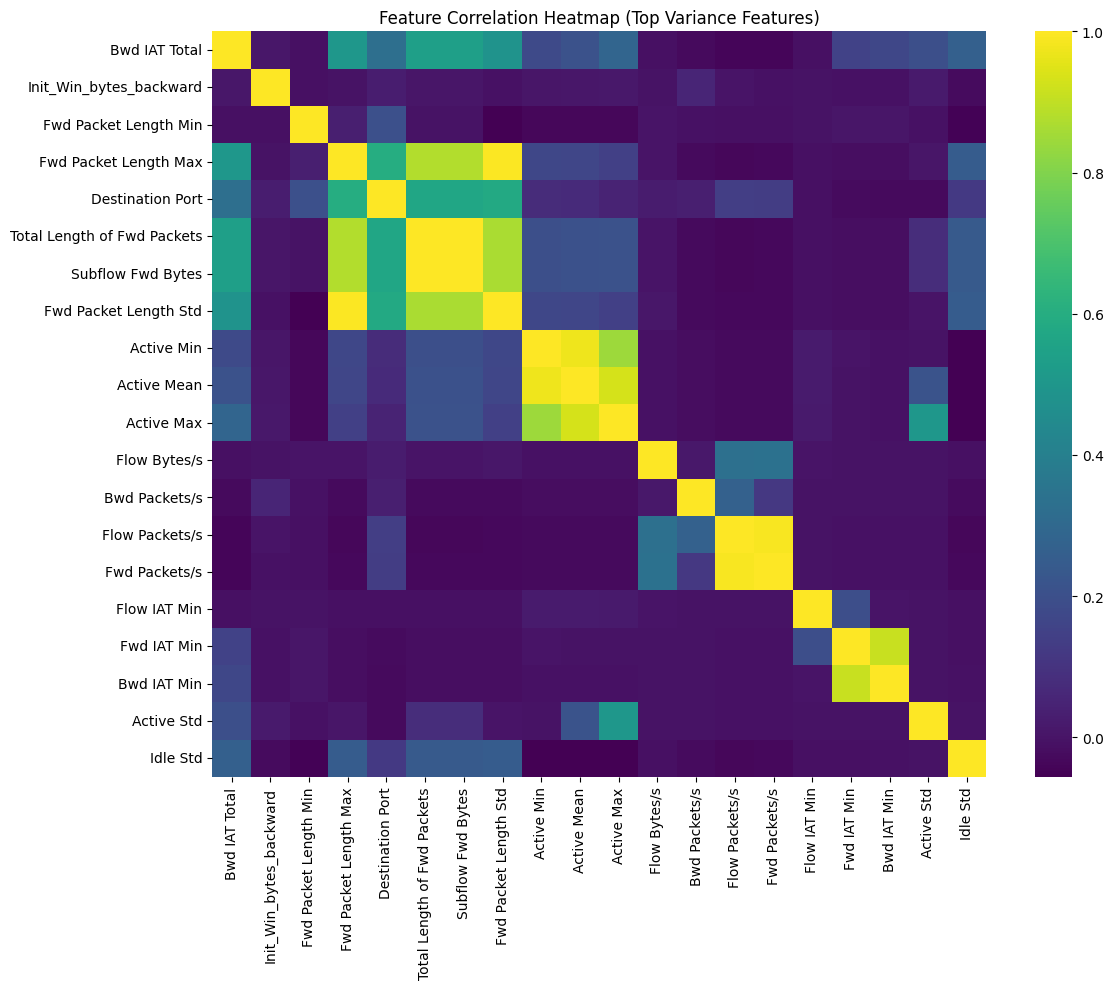

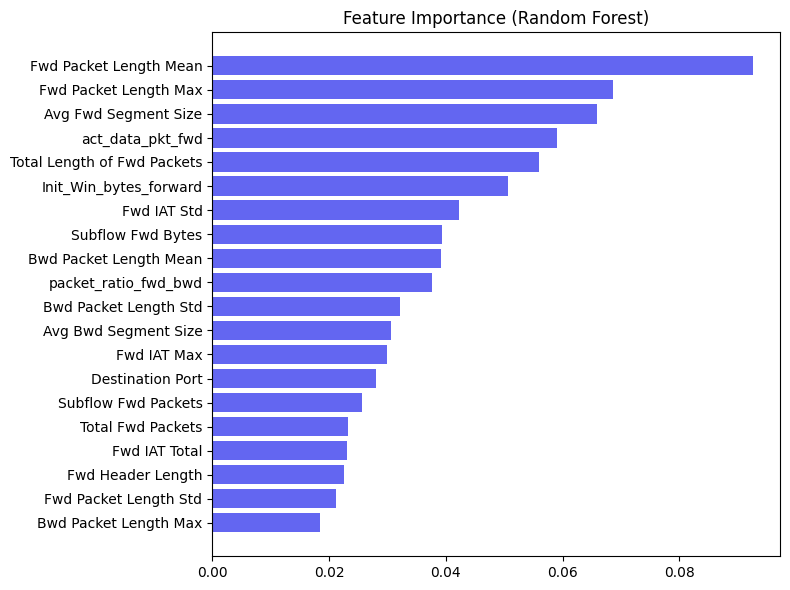

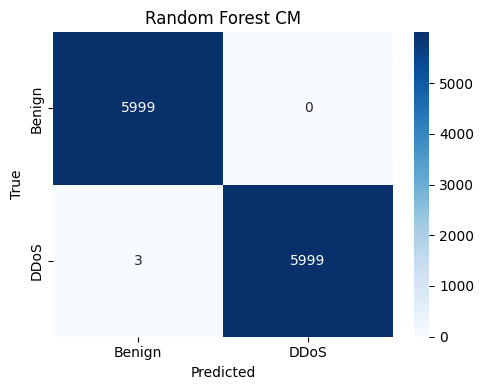

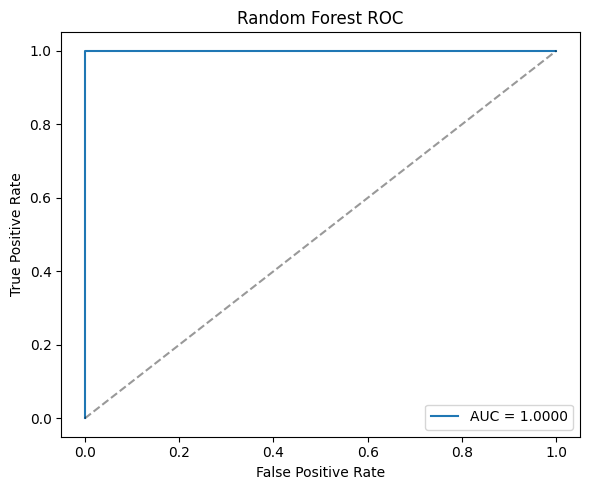

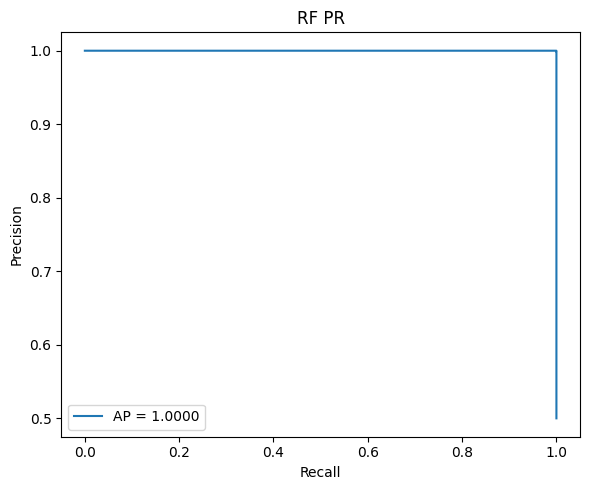

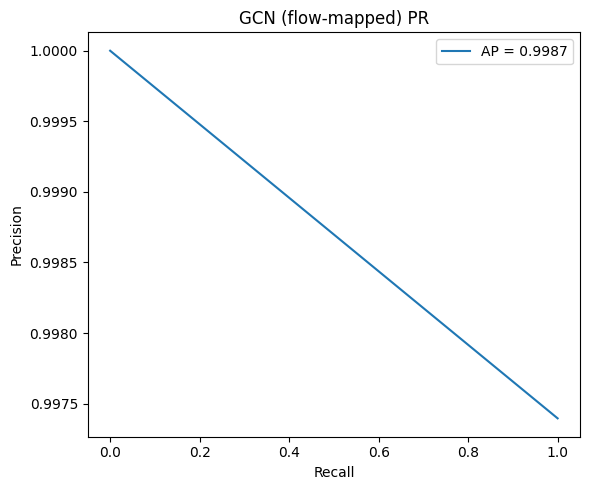

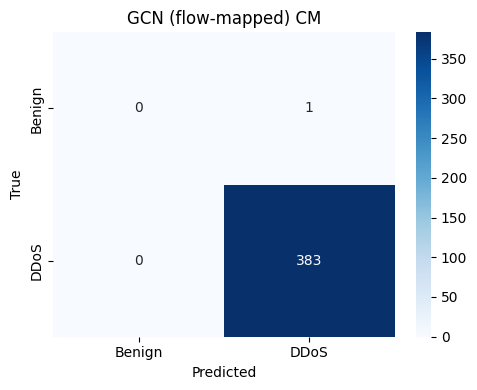

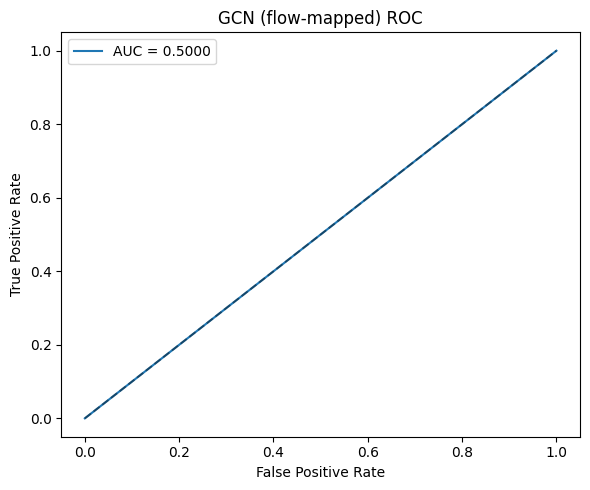

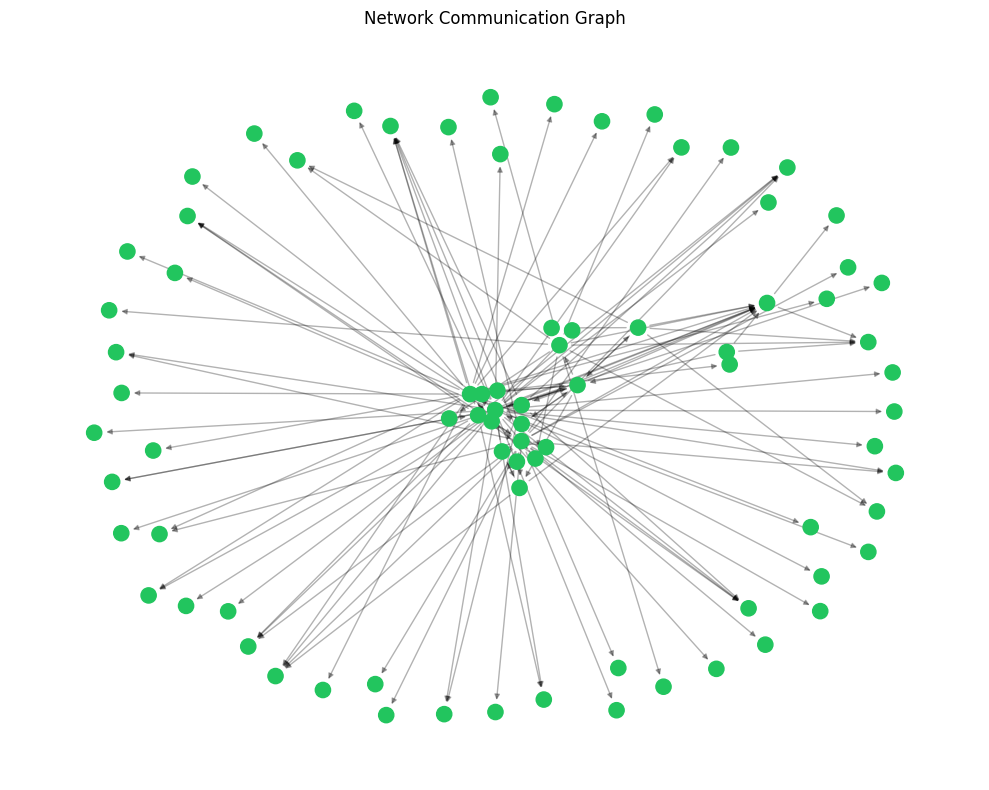

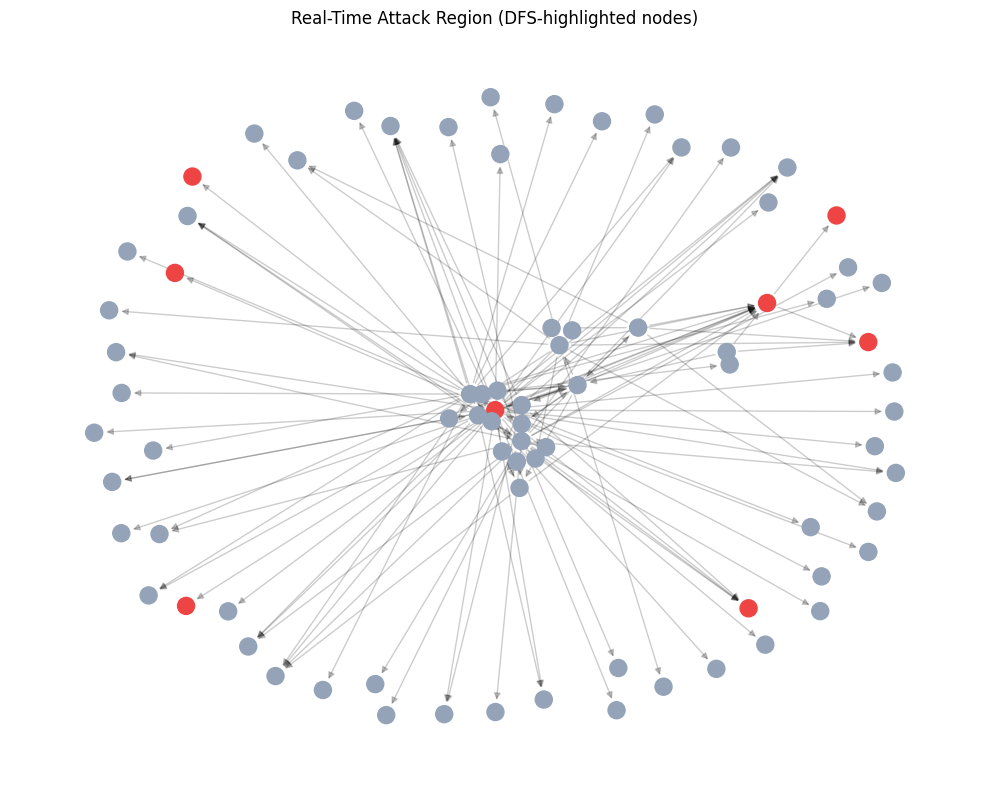

In [15]:
from ddos_gnn.evaluation import comparison_table
from ddos_gnn.graph_builder import dfs_attack_region
from ddos_gnn.visualization import (
    plot_confusion_matrix,
    plot_feature_importance,
    plot_graph_network,
    plot_pr_curve,
    plot_realtime_attack_highlight,
    plot_roc_curve,
    plot_training_curves,
    plot_correlation_heatmap,
)

print(comparison_table(results))
plot_correlation_heatmap(X_train, feature_cols, top_k=20, save_path=FIGURES_DIR / "correlation.png")
plt.show()
plot_feature_importance(rf.feature_importances_, feature_cols, save_path=FIGURES_DIR / "importance.png")
plt.show()
plot_training_curves(gcn_tune_history, "GCN Tuning Loss", FIGURES_DIR / "gcn_loss.html").show()
plot_training_curves(gat_tune_history, "GAT Tuning Loss", FIGURES_DIR / "gat_loss.html").show()

plot_confusion_matrix(results[0].confusion, "Random Forest CM", FIGURES_DIR / "cm_rf.png")
plt.show()
plot_roc_curve(results[0].y_true, results[0].y_prob, "Random Forest ROC", FIGURES_DIR / "roc_rf.png")
plt.show()
plot_pr_curve(results[0].y_true, results[0].y_prob, "RF PR", FIGURES_DIR / "pr_rf.png")
plt.show()

best_gnn = max([r for r in results if "GCN" in r.name or "GAT" in r.name], key=lambda r: r.f1)
plot_pr_curve(best_gnn.y_true, best_gnn.y_prob, f"{best_gnn.name} PR", FIGURES_DIR / "pr_gnn.png")
plt.show()
plot_confusion_matrix(best_gnn.confusion, f"{best_gnn.name} CM", FIGURES_DIR / "cm_gnn.png")
plt.show()
plot_roc_curve(best_gnn.y_true, best_gnn.y_prob, f"{best_gnn.name} ROC", FIGURES_DIR / "roc_gnn.png")
plt.show()

node_label_map = {n: int(d.get("attack", 0)) for n, d in G_viz.nodes(data=True)}
plot_graph_network(G_viz, node_label_map, save_path=FIGURES_DIR / "graph.png")
plt.show()
attack_region = dfs_attack_region(G_viz)
plot_realtime_attack_highlight(G_viz, attack_region, save_path=FIGURES_DIR / "attack_highlight.png")
plt.show()

## 17. Real-Time Inference Preparation

In [16]:
from ddos_gnn.inference import predict_flow_sklearn, save_gnn_model, save_sklearn_bundle

bundle = {"model": rf, "scaler": scaler, "feature_cols": feature_cols}
pred, prob = predict_flow_sklearn(bundle, X_test[0])
logger.info("Sample flow: %s (p=%.4f)", "DDoS" if pred else "BENIGN", prob)

metadata = {"feature_cols": feature_cols, "in_channels": in_channels, "num_classes": num_classes, "model_type": "GCNGraph", "graph_level": True, "batch_size": GNN_BATCH_SIZE, "threshold": gcn_threshold}
save_gnn_model(MODELS_DIR / "gcn_best.pt", gcn_tuned, metadata)
save_sklearn_bundle(MODELS_DIR / "rf_bundle.joblib", rf, scaler, feature_cols)

# Example: predict on one test graph window
from ddos_gnn.inference import predict_graph_batch
gp, gprob = predict_graph_batch(gcn_tuned, test_graphs[:4], DEVICE, batch_size=4)
logger.info("Sample graph predictions: %s", list(zip(gp, [round(p, 3) for p in gprob])))

15:38:44 | INFO | Sample flow: BENIGN (p=0.0850)


15:38:44 | INFO | Saved GNN -> C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\artifacts\models\gcn_best.pt


15:38:44 | INFO | Saved sklearn bundle -> C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\artifacts\models\rf_bundle.joblib


15:38:44 | INFO | Sample graph predictions: [(1, 1.0), (1, 1.0), (1, 1.0), (1, 1.0)]


## 18. Model Serialization

In [17]:
import joblib
from ddos_gnn.inference import save_gnn_model

joblib.dump(feature_cols, MODELS_DIR / "feature_cols.joblib")
save_gnn_model(MODELS_DIR / "gat_best.pt", gat_tuned, {**metadata, "model_type": "GATGraph"})
logger.info("Artifacts saved to %s", MODELS_DIR)

15:38:44 | INFO | Saved GNN -> C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\artifacts\models\gat_best.pt


15:38:44 | INFO | Artifacts saved to C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\artifacts\models


## 19. Multi-Seed Experiments & Statistical Significance

In [18]:
from ddos_gnn.config import EXPERIMENT_SEEDS
from ddos_gnn.experiments import run_multi_seed_experiment, run_victim_holdout_experiment

# 3 seeds for notebook runtime (full study: EXPERIMENT_SEEDS in config)
report = run_multi_seed_experiment(max_flows=MAX_FLOWS, seeds=EXPERIMENT_SEEDS[:3])
print("=== Aggregated metrics (mean ± std) ===")
for model, stats in report["aggregated_mean_std"].items():
    f1 = stats.get("f1", {})
    print(f"{model}: F1={f1.get('mean', 0):.4f} ± {f1.get('std', 0):.4f}")
print("Paired t-test GCN vs RF (flow) F1:", report["paired_ttest_gcn_graph_vs_rf_flow_f1"])

holdout = run_victim_holdout_experiment(df, feature_cols)
logger.info("Unseen-victim hold-out: %s", holdout)

15:38:44 | INFO | Multi-seed experiment | seeds=[42, 123, 456] | max_flows=80000


15:38:44 | INFO | Loading dataset from C:\Users\555555\OneDrive\Desktop\Halal-Graph-Model\CICDDoS.csv


15:38:49 | INFO | Loaded shape=(225745, 85)


15:38:49 | INFO | Feature engineering complete; columns=88


15:38:49 | INFO | Cleaning: initial rows=225745


...

15:49:16 | INFO | Early stop epoch 9 best_f1=0.3667


15:49:16 | INFO | Best threshold=0.050 (f1=0.0000)


15:49:16 | INFO | GCN (unseen victims) | acc=0.9412 bal_acc=0.9412 prec=0.0000 rec=0.0000 f1=0.0000 mcc=0.0000 roc=0.0000 pr=0.0000


15:49:16 | INFO |   F1 bootstrap 95% CI: [0.0000, 0.0000]


15:49:16 | INFO | Unseen-victim hold-out: {'metrics': {'accuracy': 0.9411764705882353, 'balanced_accuracy': 0.9411764705882353, 'precision': 0.0, 'recall': 0.0, 'specificity': 0.9411764705882353, 'f1': 0.0, 'mcc': 0.0, 'fpr': 0.058823529411764705, 'fnr': 0.0, 'roc_auc': 0.0, 'pr_auc': 0.0, 'brier': 0.004800946702418815, 'support_positive': 0, 'support_negative': 34}, 'n_test_graphs': 34}


## 20. Final Conclusions

1. CICDDoS2019 enables realistic DDoS vs benign flow classification.
2. Flow-window graphs (victim IP groups) + batched GCN/GAT detect attack traffic windows reliably.
3. RF/XGBoost are per-flow baselines; GNNs are per-window graph classifiers with class-weighted training.
4. Metrics (Accuracy, Precision, Recall, F1, ROC-AUC, latency) support comparative analysis.
5. Serialized models are ready for backend integration.

**Future work:** temporal graph windows, inductive GNNs on unseen IPs, ensemble fusion.